# Evaluate the results of alignment (20 and 100 frames)

In [2]:
import sys, os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *
import numpy as np
import hyperspy.api as hs
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import copy
from importlib import reload
from sklearn.preprocessing import MinMaxScaler

from skimage import data, img_as_float, feature
import tensorstore as ts
from scipy.stats import pearsonr
from datetime import datetime
import warnings
import pickle
from datetime import datetime
import gc
import psutil
from multiprocessing import Pool
from scipy.optimize import nnls
from itertools import repeat
import humanfriendly
import random
import seaborn as sns


#from torchdr import PACMAP, UMAP
import pacmap


%load_ext autoreload
%autoreload 2

### Load unaligned data

In [ ]:
# load data
file_path = "../data/EMD/EDXdataset.emd"
edx_unaligned_20, haadf_20, xray_energies = load_EDX(file_path, first_frame=0, last_frame=20, sum_frames=True, haadf_last_frame= True)
edx_unaligned_100, haadf_100, xray_energies = load_EDX(file_path, first_frame=0, last_frame=100, sum_frames=True, haadf_last_frame= True)

# Create object
tile_20 = EM_EDX(haadf_20, edx_unaligned_20, xray_energies)
tile_20.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile_20.apply("binning", parameters={"dim": (2048, 2048, 250)})

# 100 frames
tile_100 = EM_EDX(haadf_100, edx_unaligned_100, xray_energies)
tile_100.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile_100.apply("binning", parameters={"dim": (2048, 2048, 250)})

del edx_unaligned_100, edx_unaligned_20
gc.collect()

In [ ]:
# save to memory

#timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

#with open(f"results/preprocessed_edx/{timestamp}_tile_unaligned_20.pkl", "wb") as f:
#    pickle.dump(tile_20, f)

#with open(f"results/preprocessed_edx/{timestamp}_tile_unaligned_100frames.pkl", "wb") as f:
#    pickle.dump(tile_100, f)

### Load unaligned from pre-saved (faster)

In [3]:
with open('results/preprocessed_edx/20260119_132514_tile_unaligned_20.pkl', 'rb') as file:
    tile_20 = pickle.load(file)

with open('results/preprocessed_edx/20260119_132514_tile_unaligned_100frames.pkl', 'rb') as file:
    tile_100 = pickle.load(file)


tile_100.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None


### Load aligned data

In [4]:
# Load aligned dataset
with open('../preprocessing_basic/results/preprocessed_edx/20251201_142554_tile_aligned_20frames.pkl', 'rb') as file:
    tile_20_aligned = pickle.load(file)
tile_20_aligned.summary()

# Load aligned dataset
with open('../preprocessing_basic/results/preprocessed_edx/20260114_062341_tile_aligned_100frames_align2zero.pkl', 'rb') as file:
    tile_100_aligned = pickle.load(file)
tile_100_aligned.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_path=tmp/unaligned_hsi_100frames, al...","(2048, 2048)","(2048, 2048, 250)",None


### Optional: crop

In [6]:
tiles = [tile_20,tile_100,tile_20_aligned,tile_100_aligned]

for tile in tiles:
    tile.apply("crop", parameters={"crop_idx": (slice(50,tile.EDX_dim[0]-50), slice(50,tile.EDX_dim[1]-50), slice(None))})

titles = ['20 frames', '100 frames', '20 frames aligned', '100 frames aligned']

### Visualize

0 255


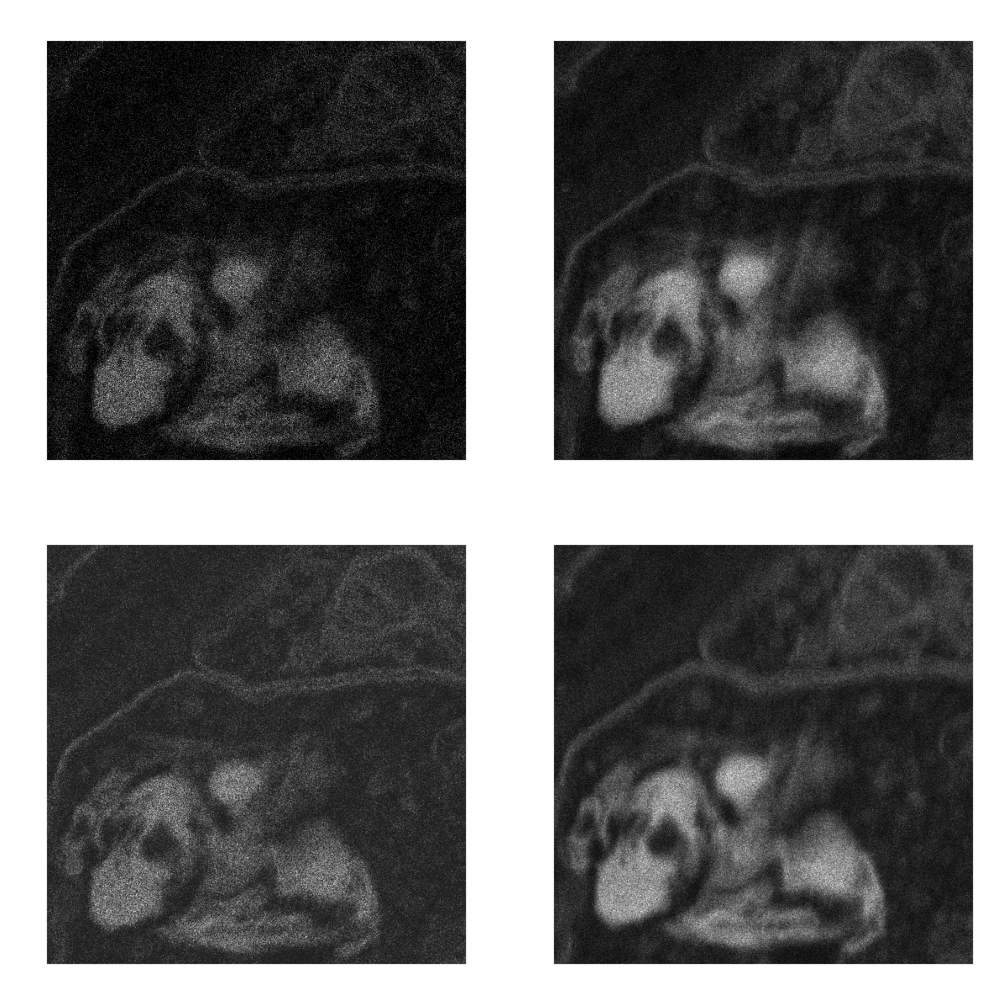

In [11]:
bands = [4,25,28]
bands = [24,24,24]


f, ax = plt.subplots(2,2,figsize=(12,12))

#roi = (slice(None),slice(None))
roi = (slice(500,1000),slice(250,750))
#roi = (slice(1150,1850),slice(1150,1850))


# get global min and max
imgs = [tiles[0].FalseColor(bands)[roi],
        tiles[1].FalseColor(bands)[roi],
        tiles[2].FalseColor(bands)[roi],
        tiles[3].FalseColor(bands)[roi]]

gmin = np.min(np.asanyarray(imgs))
gmax = np.max(np.asanyarray(imgs))

print(gmin, gmax)

ax[0][0].imshow(imgs[0],vmin=gmin,vmax=gmax)
ax[0][1].imshow(imgs[1],vmin=gmin,vmax=gmax)

ax[1][0].imshow(imgs[2],vmin=gmin,vmax=gmax)
ax[1][1].imshow(imgs[3],vmin=gmin,vmax=gmax)

ax[0][0].set_title(titles[0],fontsize=20)
ax[0][1].set_title(titles[1],fontsize=20)
ax[1][0].set_title(titles[2],fontsize=20)
ax[1][1].set_title(titles[3],fontsize=20)

#for i in range(2):
#    for j in range(2):
#        ax[i][j].axis('off')

make_dark_presentation(f,text_color='white', line_width=2.5, transparent=True)
plt.savefig("/Users/aj/Desktop/WIPfigures/visual_comparison_alignment_Os.png", dpi=300, transparent=True)

### Bin and mean-filter

In [12]:
tiles_binned = copy.deepcopy(tiles)

for tile in tiles_binned:
    tile.apply("binning", parameters={"dim": (int(tile.EDX_dim[0]/2), int(tile.EDX_dim[1]/2), 250)})
    tile.apply("MeanFilterEDX", parameters={"kernel_size": 3})


### Clean memory

In [13]:
del tile_100, tile_100_aligned, tile_20, tile_20_aligned
gc.collect()

47174

### Visual comparison (binned)

In [ ]:
bands = [4,25,28]
#bands = [24,24,24]


f, ax = plt.subplots(2,2,figsize=(12,12))

#roi = (slice(600,None),slice(600,None))
#roi = (slice(500,1000),slice(250,750))
roi = (slice(None),slice(None))

# get global min and max
imgs = [tiles_binned[0].FalseColor(bands)[roi],
        tiles_binned[1].FalseColor(bands)[roi],
        tiles_binned[2].FalseColor(bands)[roi],
        tiles_binned[3].FalseColor(bands)[roi]]

gmin = np.min(np.asanyarray(imgs))
gmax = np.max(np.asanyarray(imgs))

print(gmin, gmax)

ax[0][0].imshow(imgs[0],vmin=gmin,vmax=gmax)
ax[0][1].imshow(imgs[1],vmin=gmin,vmax=gmax)

ax[1][0].imshow(imgs[2],vmin=gmin,vmax=gmax)
ax[1][1].imshow(imgs[3],vmin=gmin,vmax=gmax)

ax[0][0].set_title(titles[0],fontsize=20)
ax[0][1].set_title(titles[1],fontsize=20)
ax[1][0].set_title(titles[2],fontsize=20)
ax[1][1].set_title(titles[3],fontsize=20)

#for i in range(2):
#    for j in range(2):
#        ax[i][j].axis('off')


### Silhouette score comparison

In [19]:
# Get the haadf
file_path = "../data/EMD/EDXdataset.emd"
_, haadf_stack, _ = load_EDX(file_path, first_frame=0, last_frame=2, sum_frames=True, haadf_last_frame= False)
haadf_stack.shape

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)


(100, 2048, 2048)

In [34]:
# Get first frame and crop it
haadf = binning_xy(haadf_stack[0,:,:])[25:1024-25,25:1024-25]

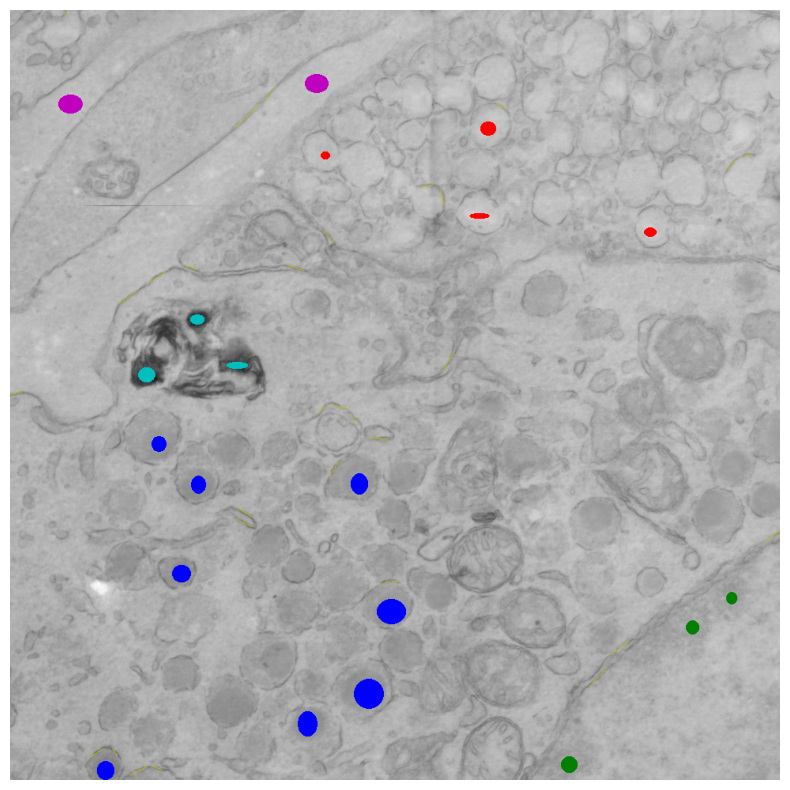

In [35]:
mask_dir = os.path.join(os.path.dirname(os.getcwd()),'data', 'masks_frame0_sil_specific')
masks = create_masks(mask_dir)

# crop masks 
masks = masks[25:1024-25,25:1024-25]

# get the hand-annotated masks and display them
colors = ['k','r','g','b','c','m','y','w']
newcmap = ListedColormap(colors)

# Normalize HAADF and invert it 
haadf_norm = (haadf - haadf.min()) / (haadf.max() - haadf.min())
haadf_norm = 1-haadf_norm

# Convert grayscale to RGB
haadf_rgb = np.dstack([haadf_norm]*3)

# Convert masks to RGB using colormap
mask_rgb = newcmap(masks)[...,:3]  # remove alpha channel

# Create output image
img = haadf_rgb.copy()

# Replace pixels where mask > 0 (or != 0 depending on your logic)
mask_pixels = masks != 0
img[mask_pixels] = mask_rgb[mask_pixels]

# Display
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')



make_dark_presentation(f,text_color='white', line_width=2.5, transparent=True)
plt.savefig("/Users/aj/Desktop/WIPfigures/ROI.png", dpi=300, transparent=True)

### Compute Silhouette scores

In [36]:
# compute sil scores for both
metric = 'euclidean'

sil_img0 = sil_scores(tiles_binned[0].EDX, masks, metric=metric)
sil_img1 = sil_scores(tiles_binned[1].EDX, masks, metric=metric)
sil_img2 = sil_scores(tiles_binned[2].EDX, masks, metric=metric)
sil_img3 = sil_scores(tiles_binned[3].EDX, masks, metric=metric)


# compute global vmin/vmax 
vmin = np.nanmin(np.array([sil_img0,sil_img1,sil_img2,sil_img3]))
vmax = np.nanmax(np.array([sil_img0,sil_img1,sil_img2,sil_img3]))

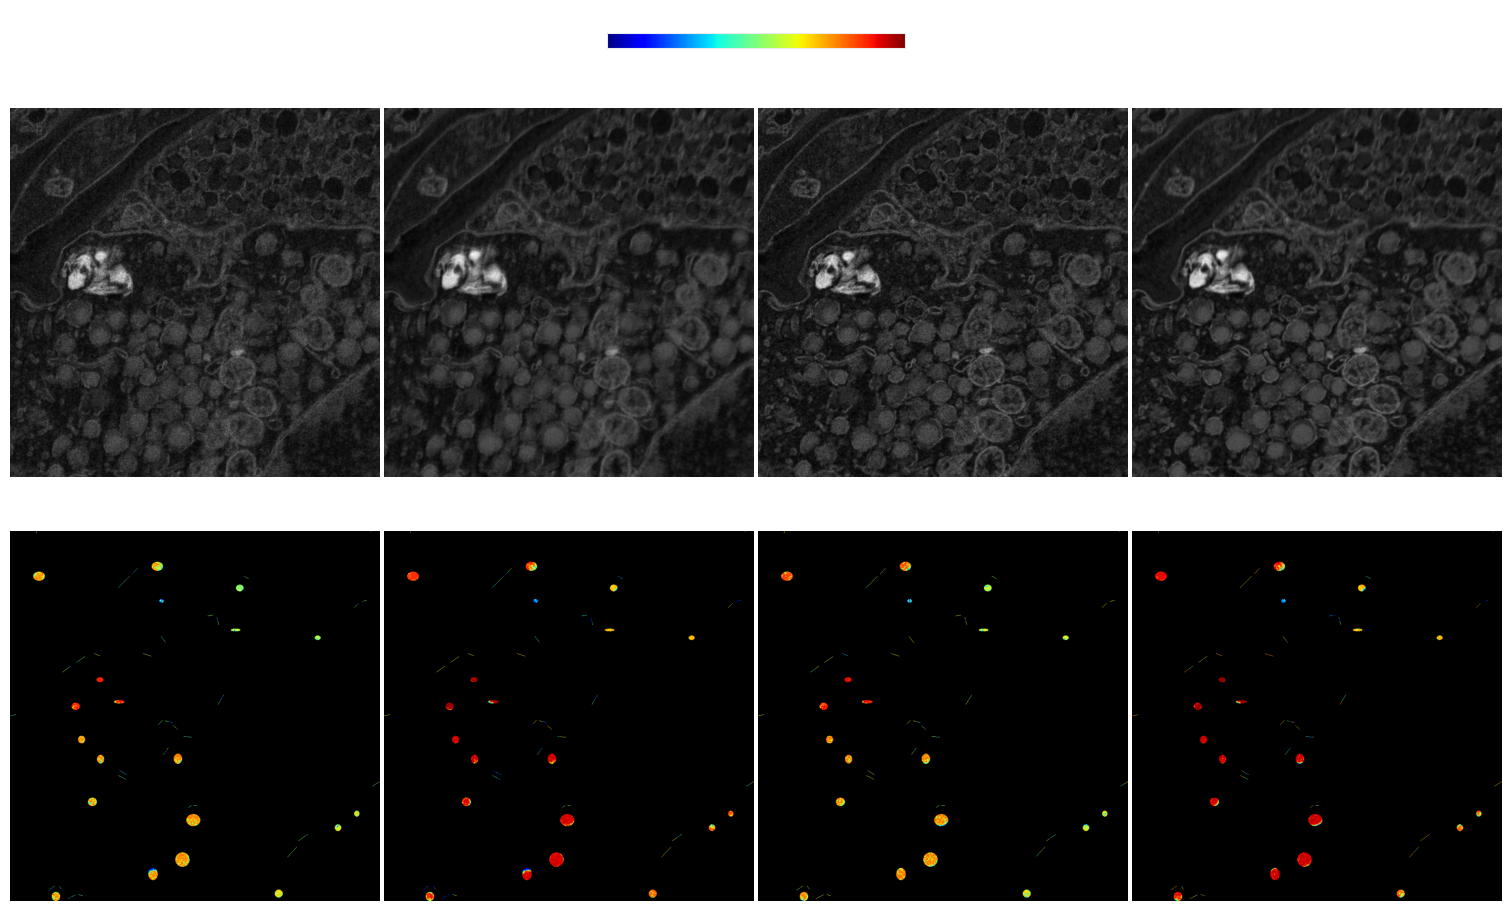

In [40]:
# modify jet so NaNs appear black
cmap = plt.cm.jet.copy()
cmap.set_bad(color='black')

bands=[24,24,24]
f, ax = plt.subplots(2,4,figsize=(15, 12))


ax[0][0].imshow(tiles_binned[0].FalseColor(bands))
ax[0][1].imshow(tiles_binned[1].FalseColor(bands))
ax[0][2].imshow(tiles_binned[2].FalseColor(bands))
ax[0][3].imshow(tiles_binned[3].FalseColor(bands))

ax[0][0].set_title(titles[0],fontsize=20)
ax[0][1].set_title(titles[1],fontsize=20)
ax[0][2].set_title(titles[2],fontsize=20)
ax[0][3].set_title(titles[3],fontsize=20)

im = ax[1][0].imshow(sil_img0,cmap=cmap,vmin=vmin,vmax=vmax)
ax[1][0].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img0),fontsize=20)

im = ax[1][1].imshow(sil_img1,cmap=cmap,vmin=vmin,vmax=vmax)
ax[1][1].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img1),fontsize=20)

im = ax[1][2].imshow(sil_img2,cmap=cmap,vmin=vmin,vmax=vmax)
ax[1][2].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img2),fontsize=20)

im = ax[1][3].imshow(sil_img3,cmap=cmap,vmin=vmin,vmax=vmax)
ax[1][3].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img3),fontsize=20)

for i in range(2):
    for j in range(4):
        ax[i][j].axis('off')

# one shared colorbar

plt.tight_layout(pad=0.3)
plt.colorbar(im, ax=ax.ravel().tolist(), shrink=0.2,location='top')


make_dark_presentation(f,text_color='white', line_width=2.5, transparent=True)
plt.savefig("/Users/aj/Desktop/WIPfigures/sil_alignment_comparison.png", dpi=300, transparent=True)

### Endmember unmixing comparison

In [ ]:
# parallelization
cpu_count = psutil.cpu_count(logical=False)

# initialize abundance maps list
abundance_maps = []


for idx,tile in enumerate(tiles_binned):
    # extract the endmembers from the masks
    nEM = 6
    endmembers = np.empty((250,nEM),float)

    for i in range(nEM):
        mask_idx = np.where(masks==i)
        #mask_idx = np.where(curr_mask)
        overlayed_spectrum = tile.EDX[mask_idx[0],mask_idx[1],:].mean(axis=0)
        endmembers[:,i] = overlayed_spectrum

    # unmix
    start = time.perf_counter()
    if __name__ == "__main__":
        with Pool(processes = cpu_count) as pool:
            unmixing = pool.starmap(nnls, zip(repeat(endmembers), tile.EDX_2D))

    abundance_maps.append(np.asarray([unmixing[i][0] for i in range(len(unmixing))]).reshape((tile.EDX_dim[0],tile.EDX_dim[1],nEM)))
    
    # time
    elapsed = time.perf_counter() - start
    print(f"Elapsed time for unmixing tile {idx:02d} is: {humanfriendly.format_timespan(elapsed):s}")



### Display abundance maps

In [ ]:
%matplotlib inline 
cmap = 'jet'

idx = 3
rows = 2
cols = 3


#titles = ['20 frames', '100 frames', '20 frames aligned', '100 frames aligned']


maps = abundance_maps[idx]
tile = tiles_binned[idx]
em_idx = 0
fig, ax = plt.subplots(rows,cols,figsize=(24,12))

for i in range(rows):
    for j in range(cols):
        try:
            ax[i][j].imshow(maps[:,:,em_idx], interpolation='nearest',cmap=cmap, vmin = 0)
        except:
            ax[i][j].imshow(np.zeros((tile.EDX_dim[0],tile.EDX_dim[0])), interpolation='nearest',cmap=cmap, vmin = 0)
            
        ax[i][j].set_title('Endmember ' + str(em_idx))
        ax[i][j].axes.get_xaxis().set_visible(False)
        ax[i][j].axes.get_yaxis().set_visible(False)
    
        em_idx+=1
 
fig = plt.gcf()
fig.suptitle(titles[idx], fontsize=22)
fig.tight_layout()   
plt.show()



### Calculate PACMAP embeddings 

In [39]:
n_samples = tiles_binned[0].EDX.shape[0]**2

# subsample
subsample_ratio = 0.3
nTrain = int(subsample_ratio*n_samples)   # number of training samples
multi_scale = False
poisson = False

# random seed
random.seed(100)
sample_idx = np.random.choice(n_samples,nTrain,replace=False)  

all_embeddings = []

for tile in tiles_binned:

    start = time.perf_counter()
    
    # PaCMAP
    reduction_model = pacmap.PaCMAP(n_components=2, n_neighbors=None, save_tree=True)

    # select the training dataset (w/o any scaling/normalizations)
    hsi_train = tile.EDX

    # get dimensions
    h, w, b = tile.EDX_dim
    
    # options (in this order)
    if poisson:       
        # Optional variance stablilzation
        G = np.mean(tile.EDX,axis=2).reshape(h*w,1)
        H = np.mean(np.mean(tile.EDX,axis=0),axis=0).reshape(b,-1)
        W = G@np.transpose(H)
        W = np.sqrt(W)    
        hsi_train = np.divide(tile.EDX,W.reshape((h,w,b)))
    
    if multi_scale:
        hsi_train = hsi_multi_scale(hsi_train,radii=[1,3,5],sigma=2)

    # fitting
    hsi_train = hsi_train.reshape((h*w,hsi_train.shape[2]))  
    reduction_model.fit(hsi_train[sample_idx,:])
    embeddings = reduction_model.embedding_
    
    # scaling (scale both reduced dimensions to 0-1)
    scaler = MinMaxScaler()
    embeddings = scaler.fit_transform(embeddings)

    # append to list
    all_embeddings.append(embeddings)

    # time
    elapsed = time.perf_counter() - start
    print(f"Elapsed time for finding pacmap embeddings: {humanfriendly.format_timespan(elapsed):s}")

Elapsed time for finding pacmap embeddings: 2 minutes and 40.09 seconds
Elapsed time for finding pacmap embeddings: 2 minutes and 40.09 seconds
Elapsed time for finding pacmap embeddings: 2 minutes and 41.56 seconds
Elapsed time for finding pacmap embeddings: 2 minutes and 41.92 seconds


### Plot embeddings

In [ ]:
%matplotlib inline 
f, ax = plt.subplots(2,2,figsize=(32,15))
sns.despine(left=True, bottom=True, right=True)


# colors
colors = ['k', 'r', 'g', 'b', 'c', 'm', 'y']
plt_colors = [colors[i] for i in masks.reshape((974**2))[sample_idx]]

# marker size
marker_size = []
for i in range(len(plt_colors)):
    if plt_colors[i] == 'k':  
        marker_size.append(0.0001)
    else:
        marker_size.append(1)

plt_idx = 0
for i in range(2):
    for j in range(2):
        ax[i][j].set_facecolor((1,1,1)) 
        ax[i][j].scatter(all_embeddings[plt_idx][:,0],all_embeddings[plt_idx][:,1], s=marker_size,c=plt_colors) 
        ax[i][j].axis('off')
        ax[i][j].set_title(titles[plt_idx],fontsize=18)
        plt_idx+=1


f.tight_layout()
plt.show()